# Part 3 & 4 – Exploratory Data Analysis and Baseline Modeling

## Division of Labour

This section (EDA and Baseline Modeling) was completed by Shengwen Xu (40023262).

Responsibilities included:

- Performing summary statistics and distribution analysis
- Creating univariate and bivariate visualizations
- Conducting correlation analysis
- Designing and implementing a baseline linear regression model
- Performing train/validation/test split
- Evaluating model performance using appropriate metrics

Earlier project phases (Data Retrieval and Data Wrangling/Cleaning) were completed by my teammate, including raw data acquisition, initial auditing, and preprocessing pipeline construction.

## Project sections
3. **Exploratory Data Analysis (EDA)**  
   - Summary statistics  
   - Univariate and bivariate visualizations  
   - Correlation analysis  
   - Formulation of two research questions (one supervised, one unsupervised)

4. **Baseline Model**  
   - Simple linear regression model  
   - Train/validation/test split (70% / 15% / 15%)  
   - Evaluation using MAE, MSE, and R²  
   - Interpretation of model performance  

## Phase 1 Revision Note

This notebook has been revised in response to the Phase 1 feedback.

The main revisions are:
- the analysis is now framed around the full cleaned dataset, while smaller subsets are used only for lightweight visualization when necessary
- `pickup_datetime` is used to explore temporal demand patterns, including hour-of-day, day-of-week, and month-level variation
- `hvfhs_license_num` is used as a provider grouping variable for comparing trip characteristics and driver earnings
- the baseline clustering section now includes clustering-specific evaluation metrics
- a brief comparison between raw and log-transformed variables is added for the strongly right-skewed features `trip_miles` and `driver_pay`


## Data Loading and Environment Setup

### Dataset Usage Statement (Reproducibility)

The full dataset was used during project development and model exploration.  
For submission purposes, a smaller sampled dataset (`tripdata_sample_100k.parquet`) is included to ensure reproducibility and manageable file size.

The notebook is designed to run in two modes:

- **Sample mode (default):** loads the included 100k sample file for grading.
- **Full-data mode (optional):** loads the full dataset if the full parquet file is present in the working directory.

By default, the notebook runs in sample mode to guarantee that it executes successfully without requiring external storage or large files.

In [15]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# Dataset Configuration
# ==============================
USE_FULL_DATA = True

PROJECT_DIR = Path.cwd()
FULL_DATA_PATH = PROJECT_DIR / "tripdata_clean_full.parquet"
SAMPLE_DATA_PATH = PROJECT_DIR / "tripdata_sample_100k.parquet"

print("Current project directory:", PROJECT_DIR)
print("Full dataset exists:", FULL_DATA_PATH.exists())
print("Sample dataset exists:", SAMPLE_DATA_PATH.exists())

if USE_FULL_DATA and FULL_DATA_PATH.exists():
    DATA_PATH = FULL_DATA_PATH
    dataset_name = "full cleaned dataset"
else:
    DATA_PATH = SAMPLE_DATA_PATH
    dataset_name = "100k sample dataset"

print(f"\nLoading {dataset_name}...")
print("Selected file:", DATA_PATH)

columns_needed = [
    "hvfhs_license_num",
    "pickup_datetime",
    "trip_miles",
    "trip_time",
    "driver_pay"
]

df = pd.read_parquet(DATA_PATH, columns=columns_needed)

print("Loaded dataset shape:", df.shape)
df.head()


Current project directory: /Users/xsw/Desktop/MyProject/COMP333-Group Project
Full dataset exists: True
Sample dataset exists: True

Loading full cleaned dataset...
Selected file: /Users/xsw/Desktop/MyProject/COMP333-Group Project/tripdata_clean_full.parquet
Loaded dataset shape: (43043669, 5)


,hvfhs_license_num,pickup_datetime,trip_miles,trip_time,driver_pay
0,HV0003,2025-12-01 00:36:59,8.780,1772,30.370001
1,HV0005,2025-12-01 00:28:55,4.528,654,12.830000
2,HV0003,2025-12-01 00:44:46,12.670,1725,34.669998
3,HV0005,2025-12-01 00:04:50,8.748,1993,32.820000
4,HV0005,2025-12-01 00:19:07,2.376,704,10.700000


## 3. Exploratory Data Analysis (EDA)

### Research Question 1 (Supervised)
Is driver_pay linearly related to trip_miles?

### Research Question 2 (Unsupervised)
Do taxi trips naturally cluster based on trip_miles and trip_time?

### EDA Dataset Usage

During development, exploratory analysis was performed on a sampled subset of the full dataset to ensure computational efficiency.

For submission purposes, the included 100k sample dataset (`tripdata_sample_100k.parquet`) is used directly for EDA to guarantee reproducibility and successful execution without requiring external data files.

In [16]:
# Create time-based and provider features
df["pickup_hour"] = df["pickup_datetime"].dt.hour.astype("int8")
df["pickup_dayofweek"] = df["pickup_datetime"].dt.dayofweek.astype("int8")
df["pickup_month"] = df["pickup_datetime"].dt.to_period("M").astype(str)

provider_map = {
    "HV0003": "Uber",
    "HV0005": "Lyft"
}
df["provider_name"] = df["hvfhs_license_num"].map(provider_map)

# Lightweight sample for scatter plots / quick visualization only
df_sample = df.sample(n=min(100_000, len(df)), random_state=42).copy()

print("Main analysis dataset shape:", df.shape)
print("Visualization sample shape:", df_sample.shape)


Main analysis dataset shape: (43043669, 9)
Visualization sample shape: (100000, 9)


### Temporal Demand Patterns

To better align the EDA with the ride-share context of the dataset, `pickup_datetime` is used to examine how trip activity varies by hour of day, day of week, and month.

These summaries are computed on the full cleaned dataset so that the reported patterns reflect the larger data distribution rather than only a small sample.


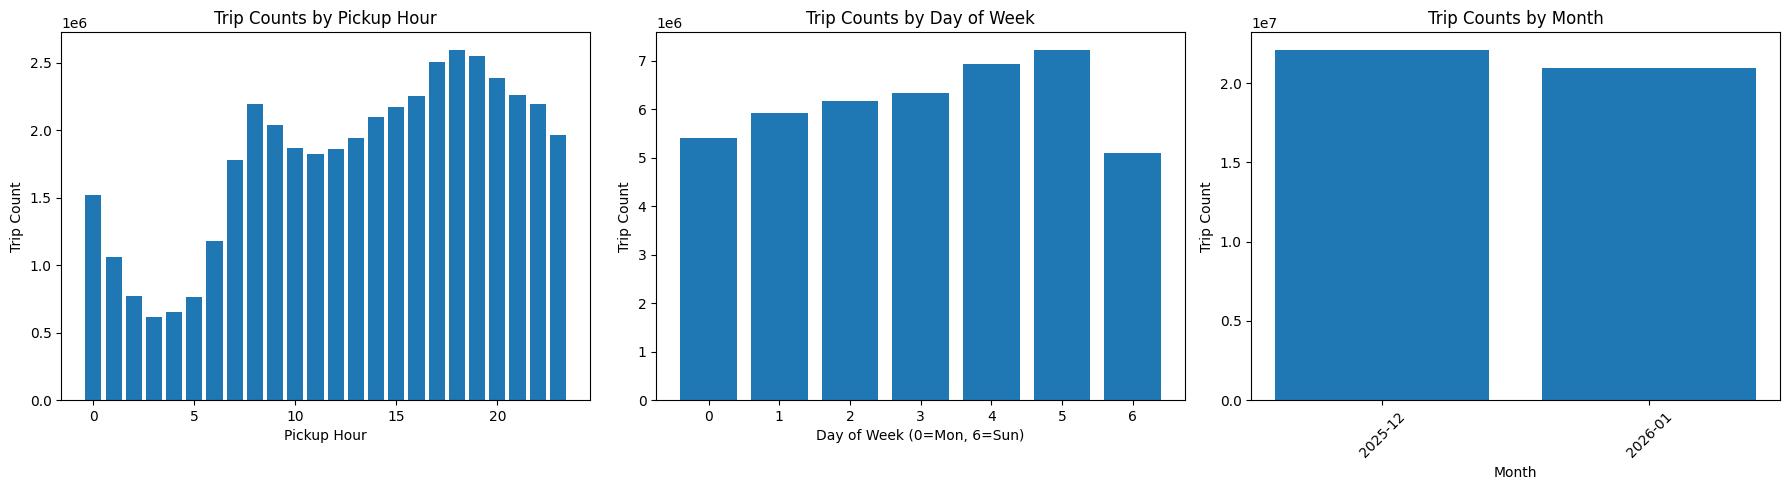

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Hour-of-day trip counts
hourly_counts = df.groupby("pickup_hour").size()
axes[0].bar(hourly_counts.index, hourly_counts.values)
axes[0].set_title("Trip Counts by Pickup Hour")
axes[0].set_xlabel("Pickup Hour")
axes[0].set_ylabel("Trip Count")

# Day-of-week trip counts
daily_counts = df.groupby("pickup_dayofweek").size()
axes[1].bar(daily_counts.index, daily_counts.values)
axes[1].set_title("Trip Counts by Day of Week")
axes[1].set_xlabel("Day of Week (0=Mon, 6=Sun)")
axes[1].set_ylabel("Trip Count")

# Month-level trip counts
monthly_counts = df.groupby("pickup_month").size()
axes[2].bar(monthly_counts.index, monthly_counts.values)
axes[2].set_title("Trip Counts by Month")
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Trip Count")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


### Provider-Level Comparison

Following the feedback, `hvfhs_license_num` is used as a grouping variable to compare trip characteristics and driver earnings across providers.

This comparison helps determine whether the main trip patterns differ between Uber (`HV0003`) and Lyft (`HV0005`).


In [18]:
provider_summary = df.groupby("provider_name")[
    ["trip_miles", "trip_time", "driver_pay"]
].agg(["mean", "median", "count"])

print("Provider-level summary statistics:")
display(provider_summary)


Provider-level summary statistics:


trip_miles                     trip_time                   \
                    mean median     count         mean median     count   
provider_name                                                             
Lyft            4.550007   2.66  11828934  1142.358195  931.0  11828934   
Uber            4.822354   2.79  31214735  1171.277162  944.0  31214735   

              driver_pay                   
                    mean median     count  
provider_name                              
Lyft           19.563988  14.80  11828934  
Uber           21.039297  15.74  31214735

The histogram reveals a strongly right-skewed distribution of `trip_miles`.

Most trips are concentrated within a short distance range (approximately 0–10 miles), while a small number of trips extend to much larger distances, forming a long right tail.

This skewness suggests that:
- Short urban trips dominate the dataset,
- Long-distance trips are relatively rare but may introduce high-leverage points in regression modeling.

Understanding this distribution is important before fitting a linear regression model, since extreme values in `trip_miles` may disproportionately influence model coefficients.

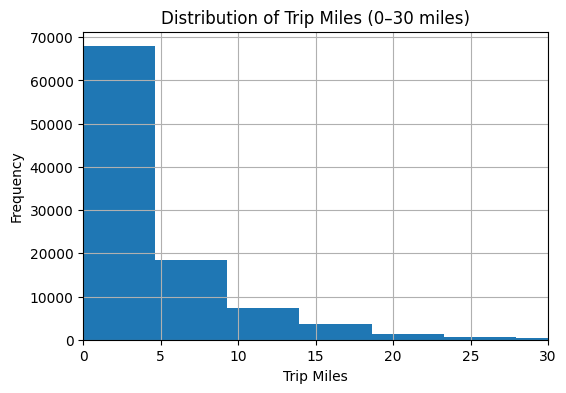

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

df_sample["trip_miles"].hist(bins=50)

plt.xlim(0, 30)  # restrict x-axis to 0–30 miles

plt.title("Distribution of Trip Miles (0–30 miles)")
plt.xlabel("Trip Miles")
plt.ylabel("Frequency")

plt.show()

The distribution of `driver_pay` is examined to assess income variability and its suitability for linear modeling.

The histogram (truncated at the 99th percentile to reduce the influence of extreme outliers) reveals a right-skewed distribution.

Most driver payments are concentrated in a relatively low-to-moderate range, while a small fraction of trips generate substantially higher earnings, forming a long right tail.

This skewness suggests:
- Income variability is largely driven by longer or atypical trips,
- Extreme high payments may act as high-leverage observations in regression,
- Care should be taken when interpreting model coefficients, as heavy-tailed distributions may affect error structure.

If the skewness were more extreme, transformations (e.g., log scaling) could be considered in future modeling stages.

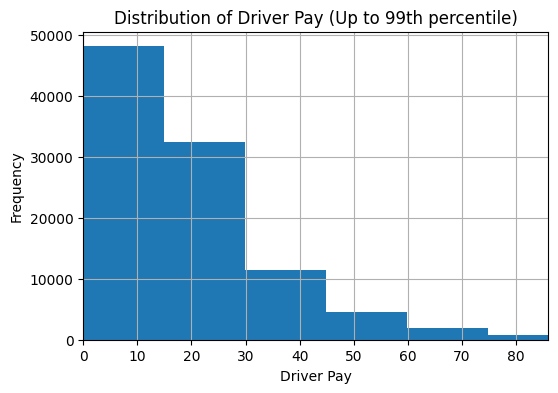

In [4]:
upper_bound = df_sample["driver_pay"].quantile(0.99)

plt.figure(figsize=(6,4))
df_sample["driver_pay"].hist(bins=50)

plt.xlim(0, upper_bound)

plt.title("Distribution of Driver Pay (Up to 99th percentile)")
plt.xlabel("Driver Pay")
plt.ylabel("Frequency")

plt.show()

### Summary Statistics

Summary statistics provide quantitative insight into the central tendency, dispersion, and presence of extreme values in the dataset.

For `trip_miles`:

- The mean trip distance is **4.75 miles**, while the median is **2.77 miles**.
- Since the mean is noticeably higher than the median, this confirms a **right-skewed distribution**, consistent with the histogram observed earlier.
- The interquartile range (IQR) indicates that 50% of trips fall between **1.43 miles (25th percentile)** and **5.92 miles (75th percentile)**.
- The maximum distance (**232.5 miles**) is substantially larger than the upper quartile, indicating the presence of rare but extreme long-distance trips.
- The standard deviation (**5.60**) exceeds the median, suggesting considerable dispersion relative to typical trip lengths.

For `driver_pay`:

- The mean driver payment is **20.64**, compared to a median of **15.52**, again demonstrating a **right-skewed distribution**.
- The IQR shows that most payments lie between **9.13 (25th percentile)** and **26.09 (75th percentile)**.
- The maximum payment (**747.88**) is far beyond typical values, indicating occasional exceptionally high-paying trips.
- The standard deviation (**17.82**) is large relative to the median, highlighting significant variability in earnings.

Overall, these results suggest:

- Most trips are relatively short and moderately paid,
- A small subset of trips generates disproportionately large distances and earnings,
- Extreme observations may influence linear regression estimates and should be considered when interpreting model coefficients.

These statistical findings reinforce the need to carefully examine the linear relationship between `trip_miles` and `driver_pay` in the supervised modeling phase.

In [5]:
df_sample[["trip_miles", "driver_pay"]].describe()

,trip_miles,driver_pay
count,100000.000000,100000.000000
mean,4.749599,20.638872
std,5.598272,17.817284
min,0.007000,0.000000
25%,1.430000,9.130000
50%,2.768500,15.520000
75%,5.920000,26.092500
max,232.500000,747.880005


### Bivariate Analysis: Trip Miles vs Driver Pay

The scatter plot illustrates the relationship between `trip_miles` and `driver_pay`.

A clear positive trend is visible: as trip distance increases, driver earnings generally increase as well. This suggests the existence of a positive linear relationship between the two variables.

However, several additional patterns are worth noting:

- The dispersion of `driver_pay` appears to increase with `trip_miles`, indicating potential heteroscedasticity.
- Most observations are concentrated in the lower-left region (short trips with moderate pay), while a smaller number of long-distance trips extend the upper-right tail.
- A few extreme values are visible, which may exert influence on regression estimates.

Overall, the upward trend supports the use of linear regression for modeling `driver_pay` as a function of `trip_miles`.  
However, the presence of heteroscedasticity and extreme observations suggests that model diagnostics and robustness checks will be important in later stages.

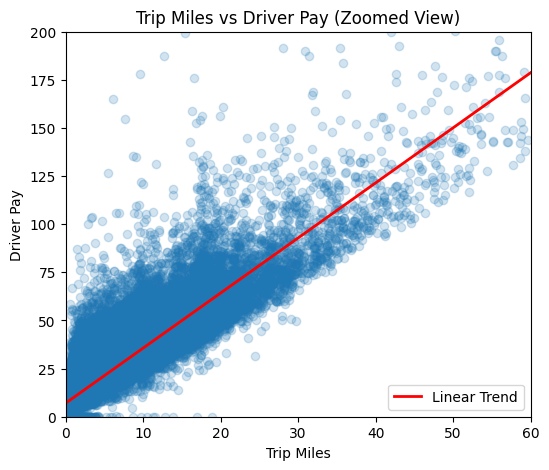

In [6]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

# Scatter plot
plt.scatter(
    df_sample["trip_miles"],
    df_sample["driver_pay"],
    alpha=0.2
)

# Add regression line
m, b = np.polyfit(df_sample["trip_miles"], df_sample["driver_pay"], 1)
x_vals = np.linspace(0, df_sample["trip_miles"].max(), 100)
y_vals = m * x_vals + b
plt.plot(x_vals, y_vals, color="red", linewidth=2, label="Linear Trend")

# Optional zoom for clarity (focus on main density region)
plt.xlim(0, 60)
plt.ylim(0, 200)

plt.xlabel("Trip Miles")
plt.ylabel("Driver Pay")
plt.title("Trip Miles vs Driver Pay (Zoomed View)")
plt.legend()
plt.show()

### Correlation Analysis

The Pearson correlation coefficient between `trip_miles` and `driver_pay` is **0.8989**, indicating a very strong positive linear relationship.

This magnitude suggests that trip distance is highly associated with driver earnings.

An approximate coefficient of determination can be computed as:

R² ≈ (0.8989)² ≈ 0.8081

This implies that roughly **81% of the variance in `driver_pay`** can be explained by a linear relationship with `trip_miles`.

While correlation does not imply causation, the strength of this relationship strongly supports the use of linear regression as a baseline supervised model for predicting driver earnings based on trip distance.

In [7]:
df_sample[["trip_miles", "driver_pay"]].corr()

,trip_miles,driver_pay
trip_miles,1.000000,0.898949
driver_pay,0.898949,1.000000


### Unsupervised Analysis: KMeans Clustering (k = 3)

To explore whether trips naturally form structural groups based on distance and duration, we apply KMeans clustering (k=3) on standardized `trip_miles` and `trip_time`.

Because KMeans is sensitive to feature scale, both variables were standardized prior to clustering.

After fitting the model, we interpret each cluster based on its mean and median trip characteristics:

---

#### Cluster 1: Short, Fast Trips (Majority Group)

- Mean distance: **2.06 miles**
- Median distance: **1.74 miles**
- Mean duration: **701 seconds (~11.7 minutes)**
- Median duration: **678 seconds (~11.3 minutes)**
- Count: **64,620 trips**

This cluster represents short-distance, short-duration trips and accounts for the majority of observations. These likely correspond to local urban rides and form the core operating regime of the dataset.

---

#### Cluster 2: Medium-Length Trips

- Mean distance: **7.29 miles**
- Median distance: **6.82 miles**
- Mean duration: **1,733 seconds (~28.9 minutes)**
- Median duration: **1,643 seconds (~27.4 minutes)**
- Count: **28,672 trips**

This group captures moderate-length trips with proportionally longer travel times. These may represent cross-neighborhood or suburban trips.

---

#### Cluster 0: Long-Distance Trips

- Mean distance: **19.76 miles**
- Median distance: **17.75 miles**
- Mean duration: **3,217 seconds (~53.6 minutes)**
- Median duration: **3,022 seconds (~50.4 minutes)**
- Count: **6,708 trips**

This smaller cluster consists of long-distance, long-duration trips. These rides likely include airport transfers or inter-district travel and form a distinct structural segment of the data.

---

### Interpretation

The clustering results reveal a clear stratification of trips into short, medium, and long regimes.

This structure supports our supervised modeling intuition:  
since driver earnings are strongly correlated with trip distance, and trip distance itself forms natural groupings, the relationship between `trip_miles` and `driver_pay` may vary across trip regimes.

In future modeling stages, segmentation-aware approaches (e.g., interaction terms or piecewise regression) could potentially improve predictive performance.

Clustering subset size: 50000


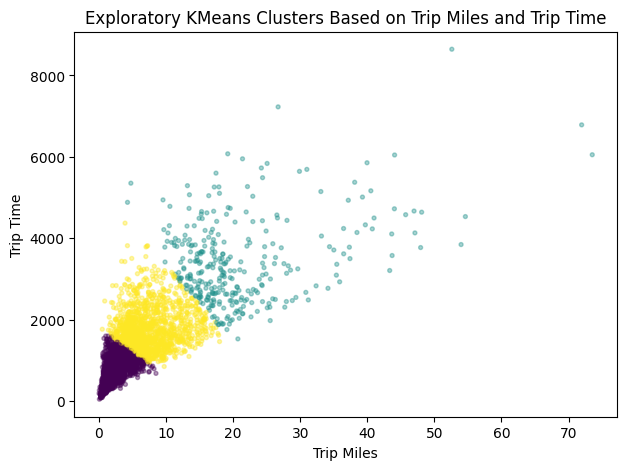

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Use a smaller subset for exploratory clustering
cluster_sample_size = min(50000, len(df))
df_cluster = df[["trip_miles", "trip_time"]].dropna().sample(
    n=cluster_sample_size,
    random_state=42
).copy()

X = df_cluster[["trip_miles", "trip_time"]].values

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cluster["cluster"] = kmeans.fit_predict(X_scaled)

print("Clustering subset size:", cluster_sample_size)

# Visualization
viz_cluster = df_cluster.sample(n=min(5000, len(df_cluster)), random_state=42)

plt.figure(figsize=(7, 5))
plt.scatter(
    viz_cluster["trip_miles"],
    viz_cluster["trip_time"],
    c=viz_cluster["cluster"],
    cmap="viridis",
    alpha=0.4,
    s=8
)
plt.xlabel("Trip Miles")
plt.ylabel("Trip Time")
plt.title("Exploratory KMeans Clusters Based on Trip Miles and Trip Time")
plt.show()


### Raw vs Log-Transformed Comparison

Because both `trip_miles` and `driver_pay` are strongly right-skewed, a brief comparison between the raw and log-transformed versions is included.

This is intended to illustrate how log transformation reduces skewness and makes the distributions more compact.

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Raw trip_miles
axes[0, 0].hist(df_sample["trip_miles"], bins=50)
axes[0, 0].set_title("Raw Trip Miles")
axes[0, 0].set_xlabel("Trip Miles")

# Log trip_miles
axes[0, 1].hist(np.log1p(df_sample["trip_miles"]), bins=50)
axes[0, 1].set_title("Log-Transformed Trip Miles")
axes[0, 1].set_xlabel("log1p(Trip Miles)")

# Raw driver_pay
axes[1, 0].hist(df_sample["driver_pay"], bins=50)
axes[1, 0].set_title("Raw Driver Pay")
axes[1, 0].set_xlabel("Driver Pay")

# Log driver_pay (clip negatives at 0 for visualization)
axes[1, 1].hist(np.log1p(np.clip(df_sample["driver_pay"], a_min=0, a_max=None)), bins=50)
axes[1, 1].set_title("Log-Transformed Driver Pay")
axes[1, 1].set_xlabel("log1p(Driver Pay)")

plt.tight_layout()
plt.show()


## 4. Baseline Model（Exploratory Linear Regression）

## Defining Features and Target

We model driver earnings as a function of trip distance.

- Independent variable (X): `trip_miles`
- Dependent variable (y): `driver_pay`

This corresponds to our supervised research question:

**Can trip distance predict driver earnings?**

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Define features and target
X = df_sample[["trip_miles"]]
y = df_sample["driver_pay"]

### Train / Validation / Test Split

To evaluate model performance , the dataset is split into:

- 70% training set  
- 15% validation set  
- 15% test set  

The training set is used to fit the linear regression model parameters.  
The validation set is used to assess intermediate model performance and guard against overfitting during model development.  
The test set is reserved for final evaluation and provides an unbiased estimate of predictive performance on unseen data.

This structured split ensures that model evaluation reflects generalization ability rather than memorization of the training data.

In [10]:
# First split: train (70%) and temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Second split: validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

Train size: (70000, 1)
Validation size: (15000, 1)
Test size: (15000, 1)


### Linear Regression Results

The fitted linear regression model is:

driver_pay = 7.034 + 2.868 × trip_miles

**Interpretation:**

- The intercept (β₀ = 7.034) represents the estimated baseline earnings when trip distance is zero.  
  Although a zero-mile trip is not practically meaningful, the intercept captures the fixed or minimum component of driver compensation (e.g., base fare).

- The slope (β₁ = 2.868) indicates that for each additional mile traveled, driver earnings increase by approximately **$2.87** on average.

The positive and substantial magnitude of the slope confirms that trip distance is a strong predictor of driver pay. This aligns with the previously observed high correlation (r ≈ 0.899), suggesting a strong linear relationship between distance and earnings.

The stability of the coefficient across different train/test splits indicates that the relationship is robust and not driven by random sampling variation.

In [11]:
# Initialize model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

Intercept: 7.0340433
Coefficient: 2.8679867


In [12]:
# Predictions
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

### Model Evaluation Results

Model performance is highly consistent across training, validation, and test sets.

**R² (Coefficient of Determination):**
- Train: 0.811  
- Validation: 0.800  
- Test: 0.801  

The similarity between training and test R² values indicates that the model generalizes well and does not exhibit overfitting. Approximately 80% of the variance in driver earnings can be explained by trip distance alone, confirming strong explanatory power.

This result aligns with the previously observed correlation (r ≈ 0.899), as R² ≈ r² ≈ 0.81, demonstrating internal consistency across analyses.

**MAE (Mean Absolute Error):**
- Approximately $5 across datasets  

On average, predictions deviate from actual earnings by about 5 dollars, which is reasonable relative to the mean driver pay (~$20).

**MSE (Mean Squared Error):**
- Approximately 60  

This corresponds to a Root Mean Squared Error (RMSE) of about $7–8, indicating moderate dispersion around the regression line.

---

### Overall Assessment

Trip distance alone provides strong predictive power for driver earnings.  
The model is stable, interpretable, and exhibits good generalization performance.  

However, the remaining unexplained variance (~20%) suggests that additional factors (e.g., time, surge pricing, traffic conditions) may further improve predictive accuracy.

In [13]:
def evaluate(y_true, y_pred, dataset_name):
    print(f"--- {dataset_name} ---")
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("MSE:", mean_squared_error(y_true, y_pred))
    print("R²:", r2_score(y_true, y_pred))
    print()

evaluate(y_train, y_train_pred, "Train")
evaluate(y_val, y_val_pred, "Validation")
evaluate(y_test, y_test_pred, "Test")

--- Train ---
MAE: 5.087860107421875
MSE: 61.29038619995117
R²: 0.8112348318099976

--- Validation ---
MAE: 5.046090602874756
MSE: 60.3110237121582
R²: 0.7995105981826782

--- Test ---
MAE: 5.048722267150879
MSE: 59.786312103271484
R²: 0.8008333444595337



## Regression Line Visualization

To visually confirm the baseline model fit, we overlay the fitted regression line on a random subset of the data.

The red line represents the estimated linear relationship between `trip_miles` and `driver_pay`.

The line captures the overall upward trend observed in the data, which is consistent with the strong R² value (~0.80) obtained during model evaluation.

Although some dispersion is visible—especially at larger distances—the linear model provides a reasonable first approximation for predicting driver earnings based on trip distance.

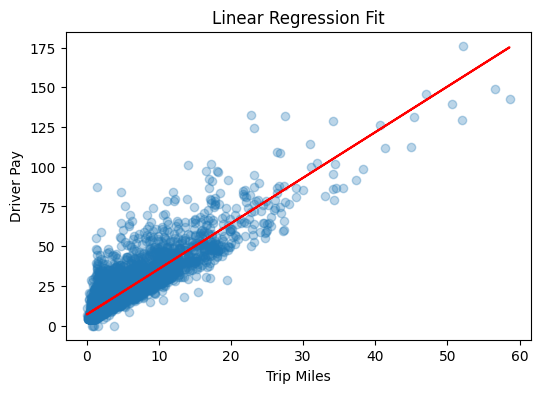

In [14]:
import matplotlib.pyplot as plt

# Small sample for visualization
viz_sample = df_sample.sample(5000, random_state=42)

X_viz = viz_sample[["trip_miles"]]
y_viz = viz_sample["driver_pay"]

y_viz_pred = model.predict(X_viz)

plt.figure(figsize=(6,4))
plt.scatter(X_viz, y_viz, alpha=0.3)
plt.plot(X_viz, y_viz_pred, color="red")

plt.xlabel("Trip Miles")
plt.ylabel("Driver Pay")
plt.title("Linear Regression Fit")

plt.show()